In [ ]:
!pip install ultralytics easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 32.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Loading Pretrained YOLO model for Vehicles Detections

In [ ]:
vehicles_detection_model = YOLO("yolov8n.pt")

In [ ]:
# By Default YOLO model is trained on COCO dataset, which contained 80 classes
vehicles_detection_model.names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [ ]:
# setting required classes
# Car --> 2
# Motorcycle --> 3
# Truck --> 7
vehicles_classes = [2, 3, 7]

# Step 1: Counting Logic

For counting vehicles crossing the specific region, we have to define the line on our image/video.

So, I load only one frame of the video and see where i can define the line




In [ ]:
import cv2
from IPython.display import Image


In [ ]:
# Load video
video_path = "/content/drive/MyDrive/Smart Cities Project/YTDown.com_YouTube_License-Plate-Detection-Test_Media_FsGPxhidwGg_001_1080p.mp4"  # file path
cap = cv2.VideoCapture(video_path)

# Read the first frame
ret, frame = cap.read()

if ret:
    # Get image height and width
    h, w, _ = frame.shape

    # Draw counting line on image
    frame = cv2.line(frame, (0, 700),(w, 700),(0, 255, 0), 2)

    # Save the frame (optional)
    cv2.imwrite("/content/drive/MyDrive/Smart Cities Project/first_frame.jpg", frame)

    cv2.waitKey(0)
else:
    print("Failed to read video")

# Release resources
cap.release()
cv2.destroyAllWindows()

In [ ]:
import  matplotlib.pyplot as plt

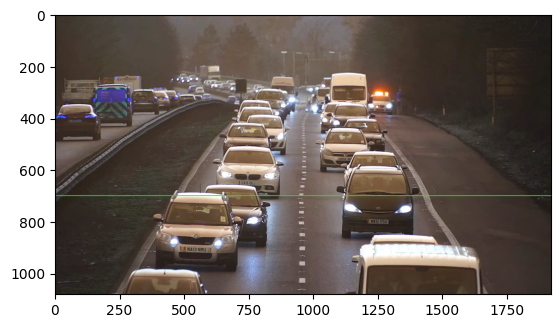

In [ ]:
plt.imshow(frame)

### from the Above Logic, we set the horizontal line position at 300 px height i.e.

Start --> (x1, y1) --> (0,700)  



End   --> (x2, y2) --> (Frame_width, 700)

## Demonstration of counting Vehicles crossing the line

Note: For counting each vehicle correctly crossing the line, It is required to track each vehicle in every frame. So we need tracker, which track vehicles in every frame, and assign unique IDs to vehicles

In [ ]:
# tracker is available in Supervison Library, SO we need to install it
!pip install supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 12.6 MB/s eta 0:00:00


In [ ]:
import supervision as sv

In [ ]:
cap = cv2.VideoCapture('/content/drive/MyDrive/Smart Cities Project/videoplayback.mp4')

# get width, height and fps of video file
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Create video writer for output video
out = cv2.VideoWriter('/content/drive/MyDrive/Smart Cities Project/videoplayback_counting.mp4',
                      cv2.VideoWriter_fourcc(*'MP4V'),
                      fps,
                      (w,h))

# for vehicles tracking
tracker = sv.ByteTrack()
# counting line start and end position
line_position = 700
start_line = (0, line_position)
end_line = (w, line_position)

tracked_vehicles = set()

# setting required classes
# Car --> 2
# Motorcycle --> 3
# Truck --> 7
vehicles_classes = [2, 3, 7]

# colors for car, truck and motorcycle
# class-wise colors (BGR)
CLASS_COLORS = {
    2: (0, 255, 0),     # Car → Green
    3: (255, 0, 0),     # Motorcycle → Blue
    7: (0, 0, 255)      # Truck → Red
}

# class-wise counts
vehicle_counts = {
    2: 0,  # car
    3: 0,  # motorcycle
    7: 0   # truck
}

# loop for iterating over each frame of video
while True:
  # read frame one by one
  ret, frame = cap.read()

  if not ret:
    print('processed Video Successfully...')
    break

  # get predictions from vehicles model
  results = vehicles_detection_model.predict(frame, conf=0.5, classes=vehicles_classes)[0]

  # for tracking, we need to convert ultralytics detections coordinates
  # to Supervison suppoted coordinates
  detections = sv.Detections.from_ultralytics(results)
  detections = tracker.update_with_detections(detections)

  # for every detected vehicles on frame -> get the bounding box, class, confidence and tracking id
  bboxes = results.boxes.xyxy.cpu()
  classes = results.boxes.cls.int().cpu().tolist()
  confidence = results.boxes.conf.cpu().tolist()
  track_ids = detections.tracker_id.tolist()

  # for iterating over each detections in the frame
  for bbox, class_id, conf, track_id in zip(bboxes, classes, confidence, track_ids):
    # get center coordinates of detections
    x1, y1, x2, y2 = bbox
    center_x = int((x1 + x2)/2)
    center_y = int((y1 + y2)/2)

    # get color based on class
    color = CLASS_COLORS.get(class_id)

    # draw bounding boxes
    cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
    # draw center coordinates on detections
    cv2.circle(frame, (center_x, center_y), 3, (0, 255, 0), -1)

    # Vehicles counting logic
    if center_y > line_position and track_id not in tracked_vehicles:
      vehicle_counts[class_id] += 1
      tracked_vehicles.add(track_id)

    # Display vehicles count
    # display counts with colors
    cv2.putText(frame, f"Car: {vehicle_counts[2]}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, CLASS_COLORS.get(2), 2)

    cv2.putText(frame, f"Motorcycle: {vehicle_counts[3]}", (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, CLASS_COLORS.get(3), 2)

    cv2.putText(frame, f"Truck: {vehicle_counts[7]}", (10, 90),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, CLASS_COLORS.get(7), 2)

  cv2.line(frame, start_line, end_line, (0, 255, 255), 2)

  out.write(frame)

cap.release()
out.release()


Streaming output truncated to the last 5000 lines.
Speed: 2.5ms preprocess, 7.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 12 cars, 6.0ms
Speed: 2.5ms preprocess, 6.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 cars, 5.8ms
Speed: 2.4ms preprocess, 5.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 12 cars, 6.0ms
Speed: 2.4ms preprocess, 6.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 13 cars, 5.9ms
Speed: 2.6ms preprocess, 5.9ms inference, 3.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 13 cars, 1 truck, 11.3ms
Speed: 2.6ms preprocess, 11.3ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 14 cars, 8.2ms
Speed: 3.2ms preprocess, 8.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 12 cars, 1 truck, 6.7ms
Speed: 2.7ms preprocess, 6.7ms inference, 1.5ms postprocess per imag

# Step 2: License plate detection  

For detecting license plate we need another YOLO model trained on license plate dataset  

The dataset will be downloaded from Roboflow:  

https://universe.roboflow.com/roboflow-universe-projects/license-plate-recognition-rxg4e



I have trained YOLO for License plate detection in another notebook. SO I am not training the model Here.

In [ ]:
License_plate_model = YOLO("/content/drive/MyDrive/Smart Cities Project/license_plate_detector.pt")

In [ ]:
import easyocr

In [ ]:
import re
from collections import defaultdict, Counter


## Preprocessing on License plate images

Get all saved license plate images by id

In [ ]:
import os

In [ ]:
base_path = "/content/drive/MyDrive/Smart Cities Project/plates_FHD"

target_id = 205  # change this

images = []

for file in os.listdir(base_path):

    if file.startswith(f"ID{target_id}_"):   # key filtering

        img_path = os.path.join(base_path, file)
        img = cv2.imread(img_path)

        if img is not None:
            images.append((file, img))

print(f"Total images for ID {target_id}: {len(images)}")

Total images for ID 205: 79


In [ ]:
import matplotlib.pyplot as plt

array([[[36, 14,  8],
        [34, 12,  6],
        [32, 10,  4],
        ...,
        [99, 84, 81],
        [97, 82, 79],
        [96, 81, 78]],

       [[44, 22, 16],
        [42, 20, 14],
        [39, 17, 11],
        ...,
        [87, 72, 69],
        [86, 71, 68],
        [85, 70, 67]],

       [[55, 33, 27],
        [53, 31, 25],
        [50, 28, 22],
        ...,
        [67, 52, 49],
        [66, 51, 48],
        [66, 51, 48]],

       ...,

       [[26, 19, 16],
        [28, 21, 18],
        [30, 23, 20],
        ...,
        [35, 27, 27],
        [35, 27, 27],
        [35, 27, 27]],

       [[30, 23, 20],
        [31, 24, 21],
        [34, 27, 24],
        ...,
        [35, 27, 27],
        [35, 27, 27],
        [35, 27, 27]],

       [[32, 25, 22],
        [34, 27, 24],
        [36, 29, 26],
        ...,
        [35, 27, 27],
        [35, 27, 27],
        [36, 28, 28]]], dtype=uint8)
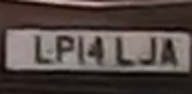

In [ ]:
images[30][1]

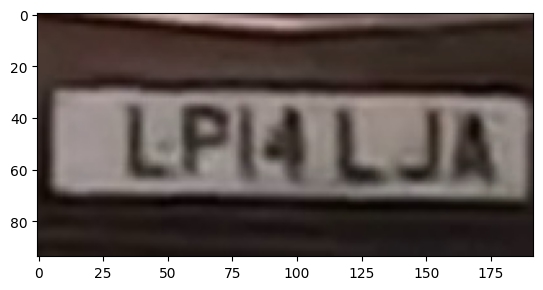

In [ ]:
plt.imshow(images[30][1])

In [ ]:
w, h

(1920, 1080)

In [ ]:
import numpy as np

In [ ]:
gray = cv2.cvtColor(images[30][1], cv2.COLOR_BGR2GRAY)


# Step 1: Upscale 6x with Lanczos interpolation
upscaled = cv2.resize(gray, (gray.shape[1] * 6, gray.shape[0] * 6),
                      interpolation=cv2.INTER_LANCZOS4)

# Step 2: Bilateral Filter
# Smooths noise while preserving edges
bilateral = cv2.bilateralFilter(upscaled, d=9, sigmaColor=60, sigmaSpace=60)

# Step 3: CLAHE - Contrast Enhancement
clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(4, 4))
enhanced = clahe.apply(bilateral)

# Step 4: Unsharp Masking
# Sharpens character edges
for _ in range(2):
    blur = cv2.GaussianBlur(enhanced, (0, 0), 2)
    enhanced = cv2.addWeighted(enhanced, 2.5, blur, -1.5, 0)

# Step 5: Gamma Correction
# Brightens mid-tones for better contrast
gamma = 1.6
lut = np.array([((i / 255.0) ** (1.0 / gamma)) * 255
                for i in range(256)]).astype(np.uint8)
brightened = cv2.LUT(enhanced, lut)

# Step 6: Otsu's Thresholding
# Auto-computes optimal threshold
_, binary = cv2.threshold(brightened, 0, 255,
                          cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Ensure text is white on black background
if np.mean(binary) > 127:
    binary = cv2.bitwise_not(binary)

# Step 7: Morphological Close
# Fills gaps/holes inside characters
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_close, iterations=1)

# Step 8: Morphological Open
# Removes small noise blobs
kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
final = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel_open, iterations=1)


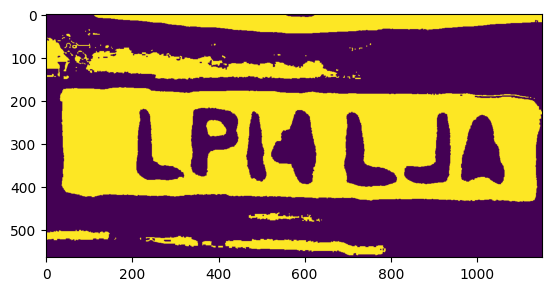

In [ ]:
plt.imshow(final)

In [ ]:
results = reader.readtext(final)

# Step 5: Display Results
print("===== OCR Results =====")
for (bbox, text, confidence) in results:
    print(f"Text       : {text}")
    print(f"Confidence : {confidence:.2f}")
    print(f"BBox       : {bbox}")
    print("-----------------------")


===== OCR Results =====
Text       : LPIALJe
Confidence : 0.26
BBox       : [[np.int32(190), np.int32(194)], [np.int32(988), np.int32(194)], [np.int32(988), np.int32(416)], [np.int32(190), np.int32(416)]]
-----------------------


In [ ]:
ocr_results

[([[np.int32(190), np.int32(194)],
   [np.int32(988), np.int32(194)],
   [np.int32(988), np.int32(416)],
   [np.int32(190), np.int32(416)]],
  'LPIALJe',
  np.float64(0.25738253226192565))]

In [ ]:
import datetime
import numpy as np

# Version 1 (Counting and License plate reading)



In [ ]:
# improvised Logics V1 - Records storing added  (working)
# output video: videoplayback_counting_&platenumber.mp4
cap = cv2.VideoCapture('/content/drive/MyDrive/Smart Cities Project/YTDown.com_YouTube_License-Plate-Detection-Test_Media_FsGPxhidwGg_001_1080p.mp4')

# get width, height and fps of input video
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# create output Video Writer instance
out = cv2.VideoWriter(
    '/content/drive/MyDrive/Smart Cities Project/videoplayback_counting_&platenumber.mp4',
    cv2.VideoWriter_fourcc(*'MP4V'),
    fps,
    (w, h)
)

# Create instance of Tracker - for Tracking vehicles in every frame
tracker = sv.ByteTrack()

# Set line position for counting logic
line_position = 700
start_line = (0, line_position)    # Starting coordinates of line
end_line = (w, line_position)      # ending coordinates of line

# setting required classes
# Car --> 2
# Motorcycle --> 3
# Truck --> 7
vehicles_classes = [2, 3, 7]

# vehicle types
vehicle_types = {
    2: "Car",
    3: "Motorcycle",
    7: "Truck"
}

# Set colors for Vehicles
CLASS_COLORS = {
    2: (0, 255, 0),   # Green for car
    3: (255, 0, 0),   # Blue for Motorcycle
    7: (0, 0, 255)    # Red for Truck
}

# initialize vehicle counting variable
vehicle_counts = {2: 0, 3: 0, 7: 0}

# Initialize instance of EasyOcr
reader = easyocr.Reader(['en'])

#
plate_history = defaultdict(list)   # track_id --> list of OCR results
plate_tracks = {}                   # stable plate
counted_ids = set()

# for storing VehicleType, TrackingID, plateNumber and Timestamp
records = {}

frame_count = 0

# Loop for iterating over every frame of input video
while True:
    # Read frame (one by one)
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # =========================
    # VEHICLE DETECTION
    # =========================
    results = vehicles_detection_model.predict(frame, conf=0.5, classes=vehicles_classes)[0]

    # convert YOLO predictions to Supervision Library format - for tracking
    detections = sv.Detections.from_ultralytics(results)
    # Track detection --> Assigning unique IDs to every vehicel detections
    detections = tracker.update_with_detections(detections)

    # get Bounding boxes i.e (x1,y1,x2,y2) of each detections
    bboxes = results.boxes.xyxy.cpu()
    # get class label of each detections i.e Car-->2, motorcycle-->3, Truck-->7
    classes = results.boxes.cls.int().cpu().tolist()
    # get tracking IDs of each detections
    track_ids = detections.tracker_id.tolist()

    vehicle_boxes = {}

    # loop for iterating over each bounding boxes, class and traking ids
    # for counting logic and drawing boxes on detections
    for bbox, class_id, track_id in zip(bboxes, classes, track_ids):
        # map x1, y2, x2, y2 coordinates to integer values
        x1, y1, x2, y2 = map(int, bbox)
        # compute centroid of bounding box
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2

        # storing coordinates by tracking id
        vehicle_boxes[track_id] = (x1, y1, x2, y2)

        # get colors by class
        color = CLASS_COLORS.get(class_id)
        # draw bounding boxes
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        # counting logic
        # If centroid of bounding boxes crosses the line
        # AND
        # tracking ID not in stored IDS
        if cy > line_position and track_id not in counted_ids:
            counted_ids.add(track_id)
            # count vehicles
            vehicle_counts[class_id] += 1

            # Records storing
            vehicle_type = vehicle_types.get(class_id)

            # get plate number - At the time of crossing the plate is not detected
            # I will update it later
            plate_number = plate_tracks.get(track_id, "Not Detected")

            timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

            records[track_id] = {
                "vehicle_type": vehicle_type,
                "track_id": track_id,
                "plate_number": plate_number,
                "timestamp": timestamp
                }

    # =========================
    # LICENSE PLATE DETECTION
    # =========================
    plate_results = License_plate_model.predict(frame, conf=0.4)[0]

    plate_detections = []

    if plate_results.boxes is not None:
        for pb in plate_results.boxes.xyxy.cpu():
            # map plate detection coordinate to integers
            px1, py1, px2, py2 = map(int, pb)
            # Crop License plate from frame --> for reading text using OCR
            plate_crop = frame[py1:py2, px1:px2]

            if plate_crop.size == 0:
                continue

            # =================================================
            # PREPROCESSING THE CROPPED LICENSE PLATE FOR OCR
            # =================================================
            # convert to gray scale image
            gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)

            # Upscale 6x with Lanczos interpolation
            upscaled = cv2.resize(gray, (gray.shape[1] * 6, gray.shape[0] * 6),
                                  interpolation=cv2.INTER_LANCZOS4)

            # Bilateral Filter
            # Smooths noise while preserving edges
            bilateral = cv2.bilateralFilter(upscaled, d=9, sigmaColor=60, sigmaSpace=60)

            # CLAHE - Contrast Enhancement
            clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(4, 4))
            enhanced = clahe.apply(bilateral)

            # Unsharp Masking
            # Sharpens character edges
            for _ in range(2):
                blur = cv2.GaussianBlur(enhanced, (0, 0), 2)
                enhanced = cv2.addWeighted(enhanced, 2.5, blur, -1.5, 0)

            # Gamma Correction
            # Brightens mid-tones for better contrast
            gamma = 1.6
            lut = np.array([((i / 255.0) ** (1.0 / gamma)) * 255
                            for i in range(256)]).astype(np.uint8)
            brightened = cv2.LUT(enhanced, lut)

            # Otsu's thresholding
            # Auto-computes optimal threshold
            _, binary = cv2.threshold(brightened, 0, 255,
                                      cv2.THRESH_BINARY + cv2.THRESH_OTSU)

            # Ensure text is white on black background
            if np.mean(binary) > 127:
                binary = cv2.bitwise_not(binary)

            # Morphological Close operation
            # Fills gaps/holes inside characters
            kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
            closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_close, iterations=1)

            # Morphological Open
            # Removes small noise blobs
            kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
            thresh = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel_open, iterations=1)

            # =================================================
            # Passing processed License plate image to OCR
            # =================================================
            ocr_results = reader.readtext(thresh)

            plate_text = ""

            print("\n===== OCR Results =====")
            for (bbox, text, confidence) in ocr_results:
                print(f"Text       : {text}")
                print(f"Confidence : {confidence:.2f}")
                print(f"BBox       : {bbox}")
                print("-----------------------")

                # Check if the ocr detection confidence is > 0.4
                # the store the plate text
                if confidence > 0.4:
                    plate_text = text.upper().replace(" ", "")

                    # regex cleaning
                    plate_text = re.sub(r'[^A-Z0-9]', '', plate_text)

            # compute centroid of License plate
            plate_center = ((px1 + px2)//2, (py1 + py2)//2)

            plate_detections.append({
                "bbox": (px1, py1, px2, py2),
                "center": plate_center,
                "text": plate_text
            })

    # =========================
    # ASSOCIATE PLATE with VEHICLE
    # =========================
    # Since Vehicle detection and License plate models are running
    # independently on the frame. If vehicle detection model detects 10
    # vehicles and License plate model detects 2 license plate. Then, we
    # do not know which license plate corresponds to which vehicle. Therefore,
    # I have written the logic to associate detected license plates with the
    # detected vehicles.

    # For iterating over each detected vehicles in the frame
    for track_id, (vx1, vy1, vx2, vy2) in vehicle_boxes.items():
        # For iterating over each detected license plate in the frame
        for plate in plate_detections:

            # get plate bbox, centeroid and text
            px1, py1, px2, py2 = plate["bbox"]
            pcx, pcy = plate["center"]
            plate_text = plate["text"]

            # Logic for associating plate with vehicle
            if vx1 < pcx < vx2 and vy1 < pcy < vy2:

                if plate_text:
                    # MULTI-FRAME VOTING
                    plate_history[track_id].append(plate_text)

                    # keep last 10 frames
                    plate_history[track_id] = plate_history[track_id][-10:]

                    # majority vote
                    stable_plate = Counter(
                        plate_history[track_id]
                    ).most_common(1)[0][0]

                    # store stable license plate text
                    plate_tracks[track_id] = stable_plate

                # update the records with plate number
                if track_id in records and plate_tracks.get(track_id):
                  records[track_id]["plate_number"] = plate_tracks[track_id]

                # draw license plate bounding box on frame
                cv2.rectangle(frame, (px1, py1), (px2, py2), (255, 255, 0), 2)

                # put license plate number on top of bounding box
                cv2.putText(
                    frame,
                    plate_tracks.get(track_id, ""),
                    (px1, py1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (255, 255, 0),
                    2
                )

    # draw counting line of the frame
    cv2.line(frame, start_line, end_line, (0, 255, 255), 2)

    # put Vehicels counting text on top-left corner of video
    cv2.putText(frame, f"Car: {vehicle_counts[2]}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, CLASS_COLORS[2], 2)

    cv2.putText(frame, f"Motorcycle: {vehicle_counts[3]}", (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, CLASS_COLORS[3], 2)

    cv2.putText(frame, f"Truck: {vehicle_counts[7]}", (10, 90),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, CLASS_COLORS[7], 2)

    # write annotated frame on output video file
    out.write(frame)

cap.release()
out.release()

Streaming output truncated to the last 5000 lines.

0: 384x640 7 cars, 10.9ms
Speed: 4.8ms preprocess, 10.9ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 license_plates, 9.1ms
Speed: 2.5ms preprocess, 9.1ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

===== OCR Results =====
Text       : 'GJo6 EPD
Confidence : 0.17
BBox       : [[0, np.int32(12)], [80, np.int32(12)], [80, np.int32(36)], [0, np.int32(36)]]
-----------------------

===== OCR Results =====

0: 384x640 9 cars, 9.2ms
Speed: 3.5ms preprocess, 9.2ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 license_plates, 10.3ms
Speed: 3.7ms preprocess, 10.3ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

===== OCR Results =====
Text       : Wi5 -ZL
Confidence : 0.14
BBox       : [[np.int32(15), np.int32(15)], [np.int32(73), np.int32(15)], [np.int32(73), np.int32(31)], [np.int32(15), np.int32(31)]]
-----------------------

===== O

## License Plate Detection and Counting (MODULAR CODE)

In [ ]:
# License Plate preprocessing function
def preprocess_plate(plate_crop):
    # Convert to grayscale
    gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)

    # Trim padding to avoid reading car body instead of plate
    pad = 3
    if gray.shape[0] > pad * 2 and gray.shape[1] > pad * 2:
        gray = gray[pad:-pad, pad:-pad]

    # Upscale 6x with Lanczos interpolation
    upscaled = cv2.resize(gray, (gray.shape[1] * 6, gray.shape[0] * 6),
                          interpolation=cv2.INTER_LANCZOS4)

    # Bilateral Filter
    # Smooth noise while preserve edges
    bilateral = cv2.bilateralFilter(upscaled, d=9, sigmaColor=60, sigmaSpace=60)

    # CLAHE - Contrast Enhancement
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(4, 4))
    enhanced = clahe.apply(bilateral)

    # Unsharp Masking
    # Sharpen character edges
    for _ in range(2):
        blur = cv2.GaussianBlur(enhanced, (0, 0), 2)
        enhanced = cv2.addWeighted(enhanced, 2.5, blur, -1.5, 0)

    # Gamma Correction
    # Brighten mid-tones for better contrast
    gamma = 1.6
    lut = np.array([((i / 255.0) ** (1.0 / gamma)) * 255
                    for i in range(256)]).astype(np.uint8)
    brightened = cv2.LUT(enhanced, lut)

    # Otsu's thresholding
    _, binary = cv2.threshold(brightened, 0, 255,
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Ensure text is white on black background
    if np.mean(binary) > 127:
        binary = cv2.bitwise_not(binary)

    # Morphological Close Operation
    # fill gaps inside characters
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_close, iterations=1)

    # Morphological Open
    # Remove small noise blobs
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    thresh = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel_open, iterations=1)

    return thresh


In [ ]:
# OCR reading
def read_plate_text(thresh):
    # Read license plate text
    ocr_results = reader.readtext(
        thresh,
        allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789', # read alphanumeric charactors
        min_size=10,
        paragraph=False
    )

    plate_text = ""
    best_conf = 0.0

    for (bbox, text, confidence) in ocr_results:
        print(f"Text: {text} | Confidence: {confidence:.2f}")

        # check if the ocr detection confidence is > 0.5
        # Then store the plate text
        if confidence > 0.5:
            cleaned = text.upper().replace(" ", "")
            cleaned = re.sub(r'[^A-Z0-9]', '', cleaned)

            # Only accept text that looks like a plate (4-8 chars)
            if 4 <= len(cleaned) <= 8 and confidence > best_conf:
                plate_text = cleaned
                best_conf = confidence

    return plate_text


In [ ]:
import datetime

# Version 2 (Counting and License plate reading)

In [ ]:
# output video: videoplayback_counting_&platenumber_v1.mp4
cap = cv2.VideoCapture('/content/drive/MyDrive/Smart Cities Project/YTDown.com_YouTube_License-Plate-Detection-Test_Media_FsGPxhidwGg_001_1080p.mp4')

# get width, height and fps of input video
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# create output Video Writer instance
out = cv2.VideoWriter(
    '/content/drive/MyDrive/Smart Cities Project/videoplayback_counting_&platenumber_v1.mp4',
    cv2.VideoWriter_fourcc(*'MP4V'),
    fps,
    (w, h)
)

# Create instance of Tracker
tracker = sv.ByteTrack()

# Set line position for counting logic
line_position = 700
start_line = (0, line_position)
end_line = (w, line_position)

# setting required classes
# Car --> 2
# Motorcycle --> 3
# Truck --> 7
vehicles_classes = [2, 3, 7]

# Vehicle types
vehicle_types = {
    2: "Car",
    3: "Motorcycle",
    7: "Truck"
}

# Colors for vehicles
CLASS_COLORS = {
    2: (0, 255, 0),    # Green for Car
    3: (255, 0, 0),    # Blue for Motorcycle
    7: (0, 0, 255)     # Red for Truck
}

# Initialize vehicle counting variable
vehicle_counts = {2: 0, 3: 0, 7: 0}

# Initialize EasyOCR instance
reader = easyocr.Reader(['en'])

plate_history = defaultdict(list)
plate_tracks = {}
counted_ids = set()

# for storing VehicleType, TrackingID, plateNumber and Timestamp
records = {}

frame_count = 0

# Loop for iterating over every frame of input video
while True:
    # Read frame (one by one)
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # =========================
    # VEHICLE DETECTION
    # =========================
    results = vehicles_detection_model.predict(frame, conf=0.5, classes=vehicles_classes)[0]

    # convert YOLO predictions to Supervision Library format - for tracking
    detections = sv.Detections.from_ultralytics(results)
    # Track detection --> Assigning unique IDs to every vehicel detections
    detections = tracker.update_with_detections(detections)

    # get Bounding boxes i.e (x1,y1,x2,y2) of each detections
    bboxes = results.boxes.xyxy.cpu()
    # get class label of each detections i.e Car-->2, motorcycle-->3, Truck-->7
    classes = results.boxes.cls.int().cpu().tolist()
    # get tracking IDs of each detections
    track_ids = detections.tracker_id.tolist()

    vehicle_boxes = {}

    # loop for iterating over each bounding boxes, class and traking ids
    # for counting logic and drawing boxes on detections
    for bbox, class_id, track_id in zip(bboxes, classes, track_ids):
        # map x1, y2, x2, y2 coordinates to integer values
        x1, y1, x2, y2 = map(int, bbox)
        # compute centroid of bounding box
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2

        # storing coordinates by tracking id
        vehicle_boxes[track_id] = (x1, y1, x2, y2)

        # get colors by class
        color = CLASS_COLORS.get(class_id)
        # draw bounding boxes
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        # counting logic
        # If centroid of bounding boxes crosses the line
        # AND
        # tracking ID not in stored IDS
        if cy > line_position and track_id not in counted_ids:
            counted_ids.add(track_id)
            # count vehicles by class ID
            vehicle_counts[class_id] += 1

            # get vehicle type
            vehicle_type = vehicle_types.get(class_id)
            # get plate number - At the time of crossing the plate is not detected
            # I will update it later
            plate_number = plate_tracks.get(track_id, "Not Detected")

            timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

            records[track_id] = {
                "vehicle_type": vehicle_type,
                "track_id": track_id,
                "plate_number": plate_number,
                "timestamp": timestamp
            }

    # =========================
    # LICENSE PLATE DETECTION
    # =========================
    plate_results = License_plate_model.predict(frame, conf=0.4)[0]

    plate_detections = []

    if plate_results.boxes is not None:
        for pb in plate_results.boxes.xyxy.cpu():
            # map plate detection coordinate to integers
            px1, py1, px2, py2 = map(int, pb)

            # Skip plates that are too small for reliable OCR
            plate_w = px2 - px1
            plate_h = py2 - py1
            if plate_w < 30 or plate_h < 10:
                continue

            # Crop License plate from frame --> for reading text using OCR
            plate_crop = frame[py1:py2, px1:px2]
            if plate_crop.size == 0:
                continue

            # Preprocess plate
            thresh = preprocess_plate(plate_crop)

            # Read plate text
            plate_text = read_plate_text(thresh)

            # compute centroid of license plate
            plate_center = ((px1 + px2) // 2, (py1 + py2) // 2)

            plate_detections.append({
                "bbox": (px1, py1, px2, py2),
                "center": plate_center,
                "text": plate_text
            })

    # =========================
    # ASSOCIATE PLATE WITH VEHICLE
    # =========================
    # Since Vehicle detection and License plate models are running
    # independently on the frame. If vehicle detection model detects 10
    # vehicles and License plate model detects 2 license plate. Then, we
    # do not know which license plate corresponds to which vehicle. Therefore,
    # I have written the logic to associate detected license plates with the
    # detected vehicles.

    # For iterating over each detected vehicles in the frame
    for track_id, (vx1, vy1, vx2, vy2) in vehicle_boxes.items():
        # iterating over each detected license plate in the frame
        for plate in plate_detections:
            # get plate bbox, centroid, text
            px1, py1, px2, py2 = plate["bbox"]
            pcx, pcy = plate["center"]
            plate_text = plate["text"]

            # logic for associting plate with vehicle
            if vx1 < pcx < vx2 and vy1 < pcy < vy2:
                if plate_text:
                    # multi frame voting
                    plate_history[track_id].append(plate_text)

                    # Keep last 15 frames
                    plate_history[track_id] = plate_history[track_id][-15:]

                    # Majority vote for stable plate
                    stable_plate = Counter(
                        plate_history[track_id]
                    ).most_common(1)[0][0]

                    # store stable license plate text
                    plate_tracks[track_id] = stable_plate

                # Update records with plate number
                if track_id in records and plate_tracks.get(track_id):
                    records[track_id]["plate_number"] = plate_tracks[track_id]

                # Draw plate bounding box
                cv2.rectangle(frame, (px1, py1), (px2, py2), (255, 255, 0), 2)

                # Display plate number
                display_text = plate_tracks.get(track_id, "")
                if display_text:
                    cv2.putText(
                        frame,
                        display_text,
                        (px1, py1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7,
                        (255, 255, 0),
                        2
                    )

    # Draw counting line
    cv2.line(frame, start_line, end_line, (0, 255, 255), 2)

    # Vehicle count display
    cv2.putText(frame, f"Car: {vehicle_counts[2]}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, CLASS_COLORS[2], 2)
    cv2.putText(frame, f"Motorcycle: {vehicle_counts[3]}", (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, CLASS_COLORS[3], 2)
    cv2.putText(frame, f"Truck: {vehicle_counts[7]}", (10, 90),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, CLASS_COLORS[7], 2)

    out.write(frame)

cap.release()
out.release()

Streaming output truncated to the last 5000 lines.

0: 384x640 14 cars, 11.1ms
Speed: 5.0ms preprocess, 11.1ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 license_plate, 12.1ms
Speed: 4.7ms preprocess, 12.1ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 14 cars, 12.7ms
Speed: 4.5ms preprocess, 12.7ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 13.0ms
Speed: 3.7ms preprocess, 13.0ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 16 cars, 11.0ms
Speed: 5.5ms preprocess, 11.0ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 license_plate, 11.7ms
Speed: 3.1ms preprocess, 11.7ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 12 cars, 9.3ms
Speed: 5.9ms preprocess, 9.3ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 9.2ms
Speed: 2.9ms prep

# Final --> Version 3 (Counting and License plate reading)

## Code with improvised counting logic (final code)

In [ ]:
# counting logic improved
# output video: videoplayback_counting_&platenumber_CL_improved_v2.mp4
cap = cv2.VideoCapture('/content/drive/MyDrive/Smart Cities Project/YTDown.com_YouTube_License-Plate-Detection-Test_Media_FsGPxhidwGg_001_1080p.mp4')

# get width, height and fps of input video
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# create output Video Writer instance
out = cv2.VideoWriter(
    '/content/drive/MyDrive/Smart Cities Project/videoplayback_counting_&platenumber_CL_improved_v2.mp4',
    cv2.VideoWriter_fourcc(*'MP4V'),
    fps,
    (w, h)
)

# Create instance of Tracker
tracker = sv.ByteTrack(track_activation_threshold=0.6,
                       minimum_matching_threshold=0.85,
                       lost_track_buffer=30,
                       frame_rate=fps)

# Set line position for counting logic
line_position = 700
start_line = (0, line_position)
end_line = (w, line_position)


zone_thickness = int(0.08 * h)   # 8% of frame height
upper_line = line_position - zone_thickness//2
lower_line = line_position + zone_thickness//2

# TRACKING MEMORY
track_states = {}
track_age = {}
prev_positions = {}

# setting required classes
# Car --> 2
# Motorcycle --> 3
# Truck --> 7
vehicles_classes = [2, 3, 7]

# Vehicle types
vehicle_types = {
    2: "Car",
    3: "Motorcycle",
    7: "Truck"
}

# Colors for vehicles
CLASS_COLORS = {
    2: (0, 255, 0),    # Green for Car
    3: (255, 0, 0),    # Blue for Motorcycle
    7: (0, 0, 255)     # Red for Truck
}

# Initialize vehicle counting variable
vehicle_counts = {2: 0, 3: 0, 7: 0}

# Initialize EasyOCR instance
reader = easyocr.Reader(['en'])

plate_history = defaultdict(list)
plate_tracks = {}
counted_ids = set()

# for storing VehicleType, TrackingID, plateNumber and Timestamp
records = {}

frame_count = 0

# Loop for iterating over every frame of input video
while True:
    # Read frame (one by one)
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # =========================
    # VEHICLE DETECTION
    # =========================
    results = vehicles_detection_model.predict(frame, conf=0.5, classes=vehicles_classes)[0]

    # convert YOLO predictions to Supervision Library format - for tracking
    detections = sv.Detections.from_ultralytics(results)
    # Track detection --> Assigning unique IDs to every vehicel detections
    detections = tracker.update_with_detections(detections)

    # get Bounding boxes i.e (x1,y1,x2,y2) of each detections
    bboxes = results.boxes.xyxy.cpu()
    # get class label of each detections i.e Car-->2, motorcycle-->3, Truck-->7
    classes = results.boxes.cls.int().cpu().tolist()
    # get tracking IDs of each detections
    track_ids = detections.tracker_id.tolist()

    vehicle_boxes = {}

    # loop for iterating over each bounding boxes, class and traking ids
    # for counting logic and drawing boxes on detections
    for bbox, class_id, track_id in zip(bboxes, classes, track_ids):
        # map x1, y2, x2, y2 coordinates to integer values
        x1, y1, x2, y2 = map(int, bbox)
        # compute centroid of bounding box
        #cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
        cy = y2

        # storing coordinates by tracking id
        vehicle_boxes[track_id] = (x1, y1, x2, y2)

        # get colors by class
        color = CLASS_COLORS.get(class_id)
        # draw bounding boxes
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        # counting logic
        # If centroid of bounding boxes crosses the line
        # AND
        # tracking ID not in stored IDS

        # track age
        track_age[track_id] = track_age.get(track_id, 0) + 1

        prev_y = prev_positions.get(track_id, cy)

        # ignore jitter
        if abs(cy - prev_y) < 2:
            prev_positions[track_id] = cy
            continue

        # determine zone
        if cy < upper_line:
            curr_state = "above"
        elif cy > lower_line:
            curr_state = "below"
        else:
            curr_state = "inside"

        prev_state = track_states.get(track_id, curr_state)

        # TRUE CROSSING
        if (prev_state == "above" and
            curr_state == "below" and
            track_id not in counted_ids and
            track_age[track_id] > 8):

            # store tracking ids
            counted_ids.add(track_id)
            # count vehicels by class
            vehicle_counts[class_id] += 1

            # get vehicel type
            vehicle_type = vehicle_types.get(class_id)
            # get plate number
            plate_number = plate_tracks.get(track_id, "Not Detected")

            # determine timestamp
            timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

            # store the records i.e. VehicelType, TrackID, PlateNumber, Timestamp
            records[track_id] = {
                "vehicle_type": vehicle_type,
                "track_id": track_id,
                "plate_number": plate_number,
                "timestamp": timestamp
            }

        track_states[track_id] = curr_state
        prev_positions[track_id] = cy

    # =========================
    # LICENSE PLATE DETECTION
    # =========================
    plate_results = License_plate_model.predict(frame, conf=0.4)[0]

    plate_detections = []

    if plate_results.boxes is not None:
        for pb in plate_results.boxes.xyxy.cpu():
            # map plate detection coordinate to integers
            px1, py1, px2, py2 = map(int, pb)

            # Skip plates that are too small for reliable OCR
            plate_w = px2 - px1
            plate_h = py2 - py1
            if plate_w < 30 or plate_h < 10:
                continue

            # Crop License plate from frame --> for reading text using OCR
            plate_crop = frame[py1:py2, px1:px2]
            if plate_crop.size == 0:
                continue

            # Preprocess plate
            thresh = preprocess_plate(plate_crop)

            # Read plate text
            plate_text = read_plate_text(thresh)

            # compute centroid of license plate
            plate_center = ((px1 + px2) // 2, (py1 + py2) // 2)

            plate_detections.append({
                "bbox": (px1, py1, px2, py2),
                "center": plate_center,
                "text": plate_text
            })

    # =========================
    # ASSOCIATE PLATE WITH VEHICLE
    # =========================
    # Since Vehicle detection and License plate models are running
    # independently on the frame. If vehicle detection model detects 10
    # vehicles and License plate model detects 2 license plate. Then, we
    # do not know which license plate corresponds to which vehicle. Therefore,
    # I have written the logic to associate detected license plates with the
    # detected vehicles.

    # For iterating over each detected vehicles in the frame
    for track_id, (vx1, vy1, vx2, vy2) in vehicle_boxes.items():
        # iterating over each detected license plate in the frame
        for plate in plate_detections:
            # get plate bbox, centroid, text
            px1, py1, px2, py2 = plate["bbox"]
            pcx, pcy = plate["center"]
            plate_text = plate["text"]

            # logic for associting plate with vehicle
            if vx1 < pcx < vx2 and vy1 < pcy < vy2:
                if plate_text:
                    # multi frame voting
                    plate_history[track_id].append(plate_text)

                    # Keep last 15 frames
                    plate_history[track_id] = plate_history[track_id][-15:]

                    # Majority vote for stable plate
                    stable_plate = Counter(
                        plate_history[track_id]
                    ).most_common(1)[0][0]

                    # store stable license plate text
                    plate_tracks[track_id] = stable_plate

                # Update records with plate number
                if track_id in records and plate_tracks.get(track_id):
                    records[track_id]["plate_number"] = plate_tracks[track_id]

                # Draw plate bounding box
                cv2.rectangle(frame, (px1, py1), (px2, py2), (255, 255, 0), 2)

                # Display plate number
                display_text = plate_tracks.get(track_id, "")
                if display_text:
                    cv2.putText(
                        frame,
                        display_text,
                        (px1, py1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7,
                        (255, 255, 0),
                        2
                    )

    # Draw counting line
    cv2.line(frame, (0, upper_line), (w, upper_line), (255,0,0), 2)
    cv2.line(frame, (0, lower_line), (w, lower_line), (0,0,255), 2)

    # Vehicle count display
    cv2.putText(frame, f"Car: {vehicle_counts[2]}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, CLASS_COLORS[2], 2)
    cv2.putText(frame, f"Motorcycle: {vehicle_counts[3]}", (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, CLASS_COLORS[3], 2)
    cv2.putText(frame, f"Truck: {vehicle_counts[7]}", (10, 90),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, CLASS_COLORS[7], 2)

    out.write(frame)

cap.release()
out.release()

Streaming output truncated to the last 5000 lines.
Speed: 4.6ms preprocess, 11.7ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 10.0ms
Speed: 3.7ms preprocess, 10.0ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 16 cars, 11.0ms
Speed: 4.5ms preprocess, 11.0ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 license_plate, 9.4ms
Speed: 3.4ms preprocess, 9.4ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 12 cars, 11.5ms
Speed: 5.7ms preprocess, 11.5ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 10.5ms
Speed: 3.5ms preprocess, 10.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 cars, 10.7ms
Speed: 3.9ms preprocess, 10.7ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 license_plate, 10.3ms
Speed: 3.7ms preprocess, 10.3ms inference, 1

In [ ]:
print("\n===== FINAL RECORDS =====")
for k, v in records.items():
    print(v)


===== FINAL RECORDS =====
{'vehicle_type': 'Car', 'track_id': 3, 'plate_number': 'NAIJNRU', 'timestamp': '2026-04-24 11:46:21'}
{'vehicle_type': 'Car', 'track_id': 4, 'plate_number': 'MSITSU', 'timestamp': '2026-04-24 11:46:21'}
{'vehicle_type': 'Car', 'track_id': 5, 'plate_number': 'Not Detected', 'timestamp': '2026-04-24 11:46:21'}
{'vehicle_type': 'Car', 'track_id': 7, 'plate_number': 'Not Detected', 'timestamp': '2026-04-24 11:46:21'}
{'vehicle_type': 'Car', 'track_id': 12, 'plate_number': 'Not Detected', 'timestamp': '2026-04-24 11:46:21'}
{'vehicle_type': 'Car', 'track_id': 6, 'plate_number': 'GXISOCJ', 'timestamp': '2026-04-24 11:48:21'}
{'vehicle_type': 'Car', 'track_id': 14, 'plate_number': 'LMIJVCV', 'timestamp': '2026-04-24 11:48:21'}
{'vehicle_type': 'Car', 'track_id': 16, 'plate_number': 'Not Detected', 'timestamp': '2026-04-24 11:49:03'}
{'vehicle_type': 'Car', 'track_id': 1, 'plate_number': 'APOSJEO', 'timestamp': '2026-04-24 11:50:06'}
{'vehicle_type': 'Car', 'track_id

In [ ]:
# storing records in csv file
import csv

csv_file = "/content/drive/MyDrive/Smart Cities Project/vehicle_records.csv"

with open(csv_file, mode='w', newline='') as file:
    writer = csv.writer(file)

    # header
    writer.writerow(["vehicle_type", "track_id", "plate_number", "timestamp"])

    # data
    for record in records.values():
        writer.writerow([
            record["vehicle_type"],
            record["track_id"],
            record["plate_number"],
            record["timestamp"]
        ])

print("CSV saved successfully!")

CSV saved successfully!


Output video (License plate reading)  
    Original      Detected  

1. NAI3NRU --------NAIJMRU  
2. MW51VSU --------MUS1VSU  
3. GX15OGJ --------GX1SOGJ  
4. LM13VCV --------LM1jVCV  
5. AP05JED         ------  
6. KM05ZZK --------KK05ZZK  
7. MR02FKD --------VR0ZFKD  
8. EYGINBG --------EYGINBG   (Exact)  
9. AV08HVF --------AWP8HVF  
10. HNI4C  -------- HNI  
11. BG65USJ --------BG65USJ   (Exact)  
12. AK64DMW --------AK64DMW   (Exact)  
13. EFI0BZT --------EFIOBZT   (Exact)  
14. KH06KSU --------KH06KSU   (Exact)  
15. GJ06EPD --------GJ06EPD   (Exact)  
16. DAO7CLX --------DAO7CLX   (Exact)  
17. BP6JLYH --------BP6JLYH   (Exact)